# Text-to-Image Generation: DynamicNetwork vs PyTorch MLP

This notebook compares **DynamicNetwork** and **PyTorch MLP** for generating 200x200 grayscale pattern images from single word inputs.

## Task
- **Input**: Single word (e.g., "stripe", "checkerboard", "gradient")
- **Output**: 200x200 grayscale pattern image (flattened to 40,000 values)

## Comparison Metrics
- MSE Loss (image reconstruction quality)
- Training Time
- Model Size (parameters)
- Visual Quality

## 1. Setup and Imports

In [11]:
#install deps

!pip install transformers datasets evaluate loralib bitsandbytes accelerate peft safetensors
!pip install scipy
!pip install scikit-learn


In [12]:
import sys
import os
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# Add paths
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
src_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, os.path.join(project_root, 'python'))
sys.path.insert(0, src_dir)

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# DynamicNetwork
from pydnn import DynamicNetwork

# Local modules
from src.pattern_generator import PatternGenerator, PATTERN_TYPES
from src.word_encoder import WordEncoder

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports successful!
PyTorch version: 2.10.0.dev20251211+cu128
Device: cuda


## 2. Pattern Types

We generate 8 distinct visual patterns:

1. **stripe** - Vertical or horizontal lines
2. **checkerboard** - Alternating squares
3. **gradient** - Linear gradient (horizontal/vertical/diagonal)
4. **dots** - Regular dot grid
5. **wave** - Sinusoidal wave pattern
6. **spiral** - Archimedean spiral
7. **grid** - Cross-hatch grid lines
8. **noise** - Structured random noise

In [13]:
# Configuration
IMAGE_SIZE = 200
OUTPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE  # 40,000
SAMPLES_PER_PATTERN = 500  # Variations per pattern
TOTAL_SAMPLES = len(PATTERN_TYPES) * SAMPLES_PER_PATTERN

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Output vector size: {OUTPUT_SIZE:,}")
print(f"Pattern types: {len(PATTERN_TYPES)}")
print(f"Samples per pattern: {SAMPLES_PER_PATTERN}")
print(f"Total samples: {TOTAL_SAMPLES:,}")
print(f"\nPatterns: {PATTERN_TYPES}")

Image size: 200x200
Output vector size: 40,000
Pattern types: 8
Samples per pattern: 500
Total samples: 4,000

Patterns: ['stripe', 'checkerboard', 'gradient', 'dots', 'wave', 'spiral', 'grid', 'noise']


## 3. Visualize Pattern Types

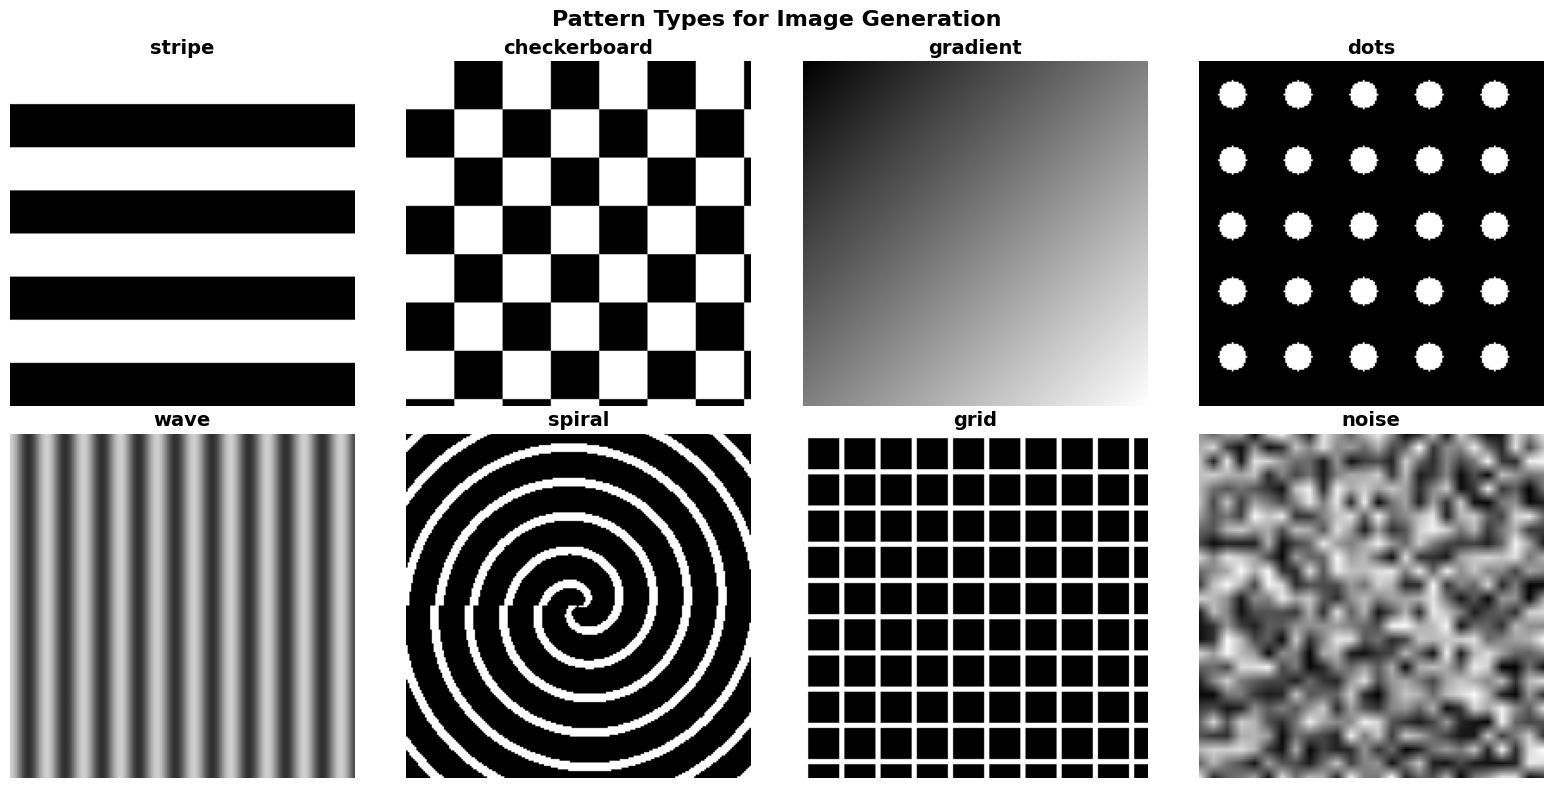

In [14]:
# Show pattern generation examples
generator = PatternGenerator(image_size=IMAGE_SIZE, seed=SEED)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, pattern_type in enumerate(PATTERN_TYPES):
    img = generator.generate(pattern_type, variation_seed=idx)
    axes[idx].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f'{pattern_type}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Pattern Types for Image Generation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Generate Dataset

In [15]:
# Generate dataset
print("Generating training dataset...")
start_time = time.time()

X_images, y_labels, pattern_names = generator.generate_dataset(samples_per_pattern=SAMPLES_PER_PATTERN)

elapsed = time.time() - start_time
print(f"Generated {len(X_images):,} images in {elapsed:.2f}s")
print(f"Image array shape: {X_images.shape}")
print(f"Memory: {X_images.nbytes / 1024 / 1024:.1f} MB")

Generating training dataset...
Generated 4,000 images in 2.45s
Image array shape: (4000, 40000)
Memory: 610.4 MB


In [16]:
# Create word encoder (one-hot encoding for pattern names)
encoder = WordEncoder(vocabulary=PATTERN_TYPES)

# Encode all labels
X_words = encoder.encode_batch(y_labels)

print(f"Word vocabulary size: {encoder.vocab_size}")
print(f"Encoded words shape: {X_words.shape}")
print(f"\nSample encodings:")
for i, pattern in enumerate(PATTERN_TYPES):
    print(f"  '{pattern}' -> {encoder.encode(i)}")

Word vocabulary size: 8
Encoded words shape: (4000, 8)

Sample encodings:
  'stripe' -> [1. 0. 0. 0. 0. 0. 0. 0.]
  'checkerboard' -> [0. 1. 0. 0. 0. 0. 0. 0.]
  'gradient' -> [0. 0. 1. 0. 0. 0. 0. 0.]
  'dots' -> [0. 0. 0. 1. 0. 0. 0. 0.]
  'wave' -> [0. 0. 0. 0. 1. 0. 0. 0.]
  'spiral' -> [0. 0. 0. 0. 0. 1. 0. 0.]
  'grid' -> [0. 0. 0. 0. 0. 0. 1. 0.]
  'noise' -> [0. 0. 0. 0. 0. 0. 0. 1.]


In [17]:
# Train/Test split
X_train_words, X_test_words, y_train_images, y_test_images = train_test_split(
    X_words, X_images, 
    test_size=0.2, 
    random_state=SEED,
    stratify=y_labels
)

# Also split labels for evaluation
_, _, y_train_labels, y_test_labels = train_test_split(
    X_words, y_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=y_labels
)

print(f"Training set: {len(X_train_words):,} samples")
print(f"Test set: {len(X_test_words):,} samples")
print(f"\nInput shape (word encoding): {X_train_words.shape}")
print(f"Output shape (image): {y_train_images.shape}")

Training set: 3,200 samples
Test set: 800 samples

Input shape (word encoding): (3200, 8)
Output shape (image): (3200, 40000)


---
## 5. DynamicNetwork Training

Train DynamicNetwork with:
- **Input**: One-hot encoded word (8 dimensions for 8 patterns)
- **Output**: Flattened 200x200 image (40,000 dimensions)
- **Cost function**: MSE (for image reconstruction)

In [18]:
# Create and train DynamicNetwork
print("=" * 60)
print("DYNAMIC NEURAL NETWORK TRAINING")
print("=" * 60)
print("Note: DynamicNetwork uses C++ backend (CPU-only)")

dnn = DynamicNetwork(
    input_shape=(encoder.vocab_size,),  # One-hot word encoding (8)
    output_size=OUTPUT_SIZE,             # 40000 pixel values
    seed=SEED,
    cost_function="MSE"
)

print(f"Input shape: {dnn.input_shape}")
print(f"Output size: {dnn.output_size}")
print(f"Cost function: {dnn.cost_function}")

# Training callback to track progress
dnn_history = {'cost': [], 'efficiency': []}

def dnn_callback(epoch, cost, efficiency):
    dnn_history['cost'].append(cost)
    dnn_history['efficiency'].append(efficiency)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: cost={cost:.6f}, efficiency={efficiency:.4f}")

print("\nStarting training...")
dnn_start = time.time()
dnn_result = dnn.fit(X_train_words, y_train_images, callback=dnn_callback, verbose=False)
dnn_time = time.time() - dnn_start

print(f"\nTraining completed in {dnn_time:.2f}s")
print(f"Final cost: {dnn_result.final_cost:.6f}")
print(f"Epochs: {dnn_result.epochs_completed}")

DYNAMIC NEURAL NETWORK TRAINING
Note: DynamicNetwork uses C++ backend (CPU-only)
Input shape: (8,)
Output size: 40000
Cost function: MSE

Starting training...
Epoch 0: cost=9.222861, efficiency=0.5000
Epoch 20: cost=1.000278, efficiency=0.4991
Epoch 120: cost=1.000089, efficiency=0.5012
Epoch 140: cost=1.000070, efficiency=0.5000
Epoch 160: cost=1.000068, efficiency=0.4999

Training completed in 206.03s
Final cost: 1.000064
Epochs: 84


In [19]:
# Evaluate DynamicNetwork
dnn_predictions = dnn.predict(X_test_words)

# Calculate MSE
dnn_mse = np.mean((dnn_predictions - y_test_images) ** 2)
print(f"DNN Test MSE: {dnn_mse:.6f}")

# Network health
health = dnn.health_status()
print(f"\nNetwork Health:")
print(f"  State: {health.state}")
print(f"  Layers: {health.current_layers}")
print(f"  Nodes: {health.current_nodes}")
print(f"  Cancer Score: {health.cancer_score:.2%}")
print(f"  Alzheimer Score: {health.alzheimer_score:.2%}")

# Efficiency report
efficiency = dnn.efficiency_report()
print(f"\nEfficiency Report:")
print(f"  Parameters: {efficiency['total_parameters']:,}")

DNN Test MSE: 0.165839

Network Health:
  State: Healthy
  Layers: 6
  Nodes: 40080
  Cancer Score: 0.00%
  Alzheimer Score: 0.00%

Efficiency Report:
  Parameters: 681,232


---
## 6. PyTorch MLP Training

Train a standard MLP with:
- **Architecture**: 8 -> 64 -> 128 -> 256 -> 40000
- **Activation**: ReLU (hidden), Sigmoid (output)
- **Optimizer**: Adam with learning rate scheduling

In [20]:
class ImageGeneratorMLP(nn.Module):
    """
    Standard MLP for image generation.
    Maps word embeddings to flattened images.
    """
    
    def __init__(self, input_size, output_size, hidden_sizes=(64, 128, 256)):
        super(ImageGeneratorMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(0.1))
            prev_size = hidden_size
        
        # Output layer with sigmoid for [0,1] pixel values
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        self.input_size = input_size
        self.output_size = output_size
        
    def forward(self, x):
        return self.network(x)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Create model
mlp = ImageGeneratorMLP(
    input_size=encoder.vocab_size,
    output_size=OUTPUT_SIZE,
    hidden_sizes=(64, 128, 256)
)

print(f"PyTorch MLP Architecture:")
print(f"  Input: {encoder.vocab_size}")
print(f"  Hidden: 512 -> 1024 -> 2048")
print(f"  Output: {OUTPUT_SIZE:,}")
print(f"  Parameters: {mlp.count_parameters():,}")

PyTorch MLP Architecture:
  Input: 8
  Hidden: 512 -> 1024 -> 2048
  Output: 40,000
  Parameters: 10,322,816


In [21]:
print("=" * 60)
print("PYTORCH MLP TRAINING")
print("=" * 60)

# Force CUDA and verify availability
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available! Please check your GPU installation.")

device = torch.device('cuda')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Clear any previous CUDA cache
torch.cuda.empty_cache()

mlp = mlp.to(device)

# Convert to tensors and move to GPU
X_train_t = torch.FloatTensor(X_train_words).to(device)
y_train_t = torch.FloatTensor(y_train_images).to(device)
X_test_t = torch.FloatTensor(X_test_words).to(device)
y_test_t = torch.FloatTensor(y_test_images).to(device)

print(f"Training data on: {X_train_t.device}")

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

mlp_history = []
mlp_start = time.time()
num_epochs = 100

print("\nStarting training...")
for epoch in range(num_epochs):
    mlp.train()
    epoch_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mlp(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    mlp_history.append(avg_loss)
    scheduler.step(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss={avg_loss:.6f}, lr={optimizer.param_groups[0]['lr']:.6f}")

mlp_time = time.time() - mlp_start
print(f"\nTraining completed in {mlp_time:.2f}s")
print(f"Final loss: {mlp_history[-1]:.6f}")

PYTORCH MLP TRAINING
Device: cuda
GPU: NVIDIA GeForce RTX 5080
GPU Memory: 15.9 GB
Training data on: cuda:0

Starting training...
Epoch 0: loss=0.146489, lr=0.001000
Epoch 10: loss=0.129220, lr=0.001000
Epoch 20: loss=0.128634, lr=0.001000
Epoch 30: loss=0.128419, lr=0.001000
Epoch 40: loss=0.128311, lr=0.001000
Epoch 50: loss=0.128152, lr=0.000500
Epoch 60: loss=0.127942, lr=0.000500
Epoch 70: loss=0.127973, lr=0.000250
Epoch 80: loss=0.127886, lr=0.000250
Epoch 90: loss=0.127938, lr=0.000125

Training completed in 21.32s
Final loss: 0.127820


In [22]:
# Evaluate PyTorch MLP
mlp.eval()
with torch.no_grad():
    mlp_predictions = mlp(X_test_t).cpu().numpy()

mlp_mse = np.mean((mlp_predictions - y_test_images) ** 2)
print(f"MLP Test MSE: {mlp_mse:.6f}")

MLP Test MSE: 0.129475


---
## 7. Comparison: DynamicNetwork vs PyTorch MLP

In [23]:
print("=" * 70)
print("COMPARISON: DynamicNetwork vs PyTorch MLP")
print("=" * 70)

dnn_params = efficiency['total_parameters']
mlp_params = mlp.count_parameters()

print(f"\n{'Metric':<25} {'DynamicNetwork':>20} {'PyTorch MLP':>20}")
print("-" * 65)
print(f"{'Test MSE':<25} {dnn_mse:>20.6f} {mlp_mse:>20.6f}")
print(f"{'Training Time (s)':<25} {dnn_time:>20.2f} {mlp_time:>20.2f}")
print(f"{'Parameters':<25} {dnn_params:>20,} {mlp_params:>20,}")
print(f"{'Epochs':<25} {dnn_result.epochs_completed:>20} {num_epochs:>20}")

winner_mse = "DynamicNetwork" if dnn_mse < mlp_mse else "PyTorch MLP"
winner_time = "DynamicNetwork" if dnn_time < mlp_time else "PyTorch MLP"
winner_params = "DynamicNetwork" if dnn_params < mlp_params else "PyTorch MLP"

print(f"\n{'Winner (MSE)':<25} {winner_mse:>40}")
print(f"{'Winner (Time)':<25} {winner_time:>40}")
print(f"{'Winner (Parameters)':<25} {winner_params:>40}")

COMPARISON: DynamicNetwork vs PyTorch MLP

Metric                          DynamicNetwork          PyTorch MLP
-----------------------------------------------------------------
Test MSE                              0.165839             0.129475
Training Time (s)                       206.03                21.32
Parameters                             681,232           10,322,816
Epochs                                      84                  100

Winner (MSE)                                           PyTorch MLP
Winner (Time)                                          PyTorch MLP
Winner (Parameters)                                 DynamicNetwork


### Training Curves Comparison

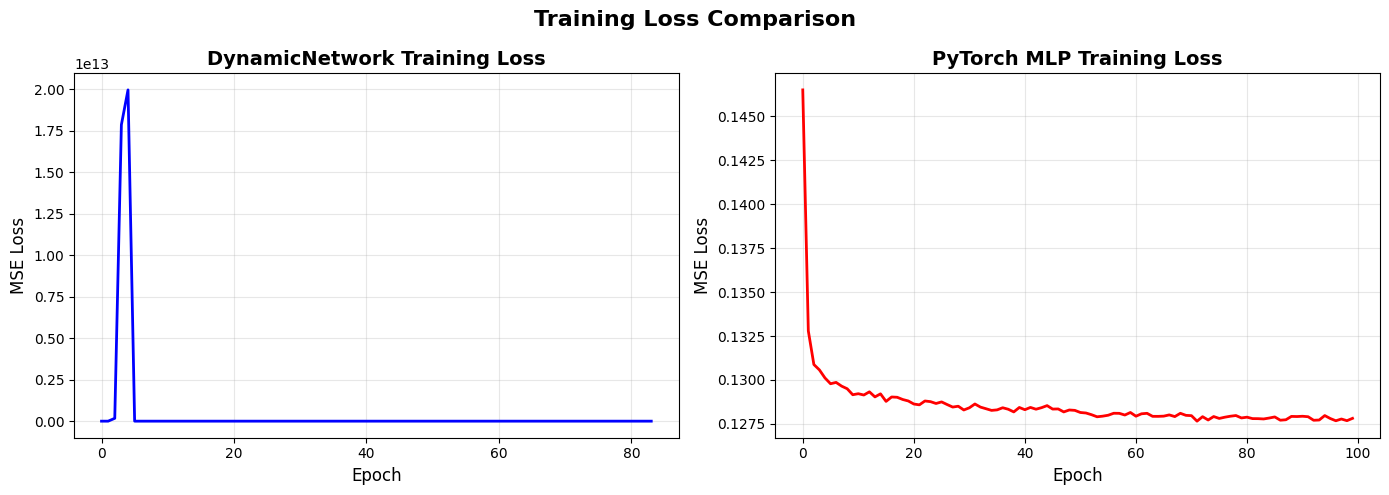

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DNN training curve
ax1 = axes[0]
ax1.plot(dnn_history['cost'], 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('DynamicNetwork Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# MLP training curve
ax2 = axes[1]
ax2.plot(mlp_history, 'r-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MSE Loss', fontsize=12)
ax2.set_title('PyTorch MLP Training Loss', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Loss Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Visual Comparison - Generated Images

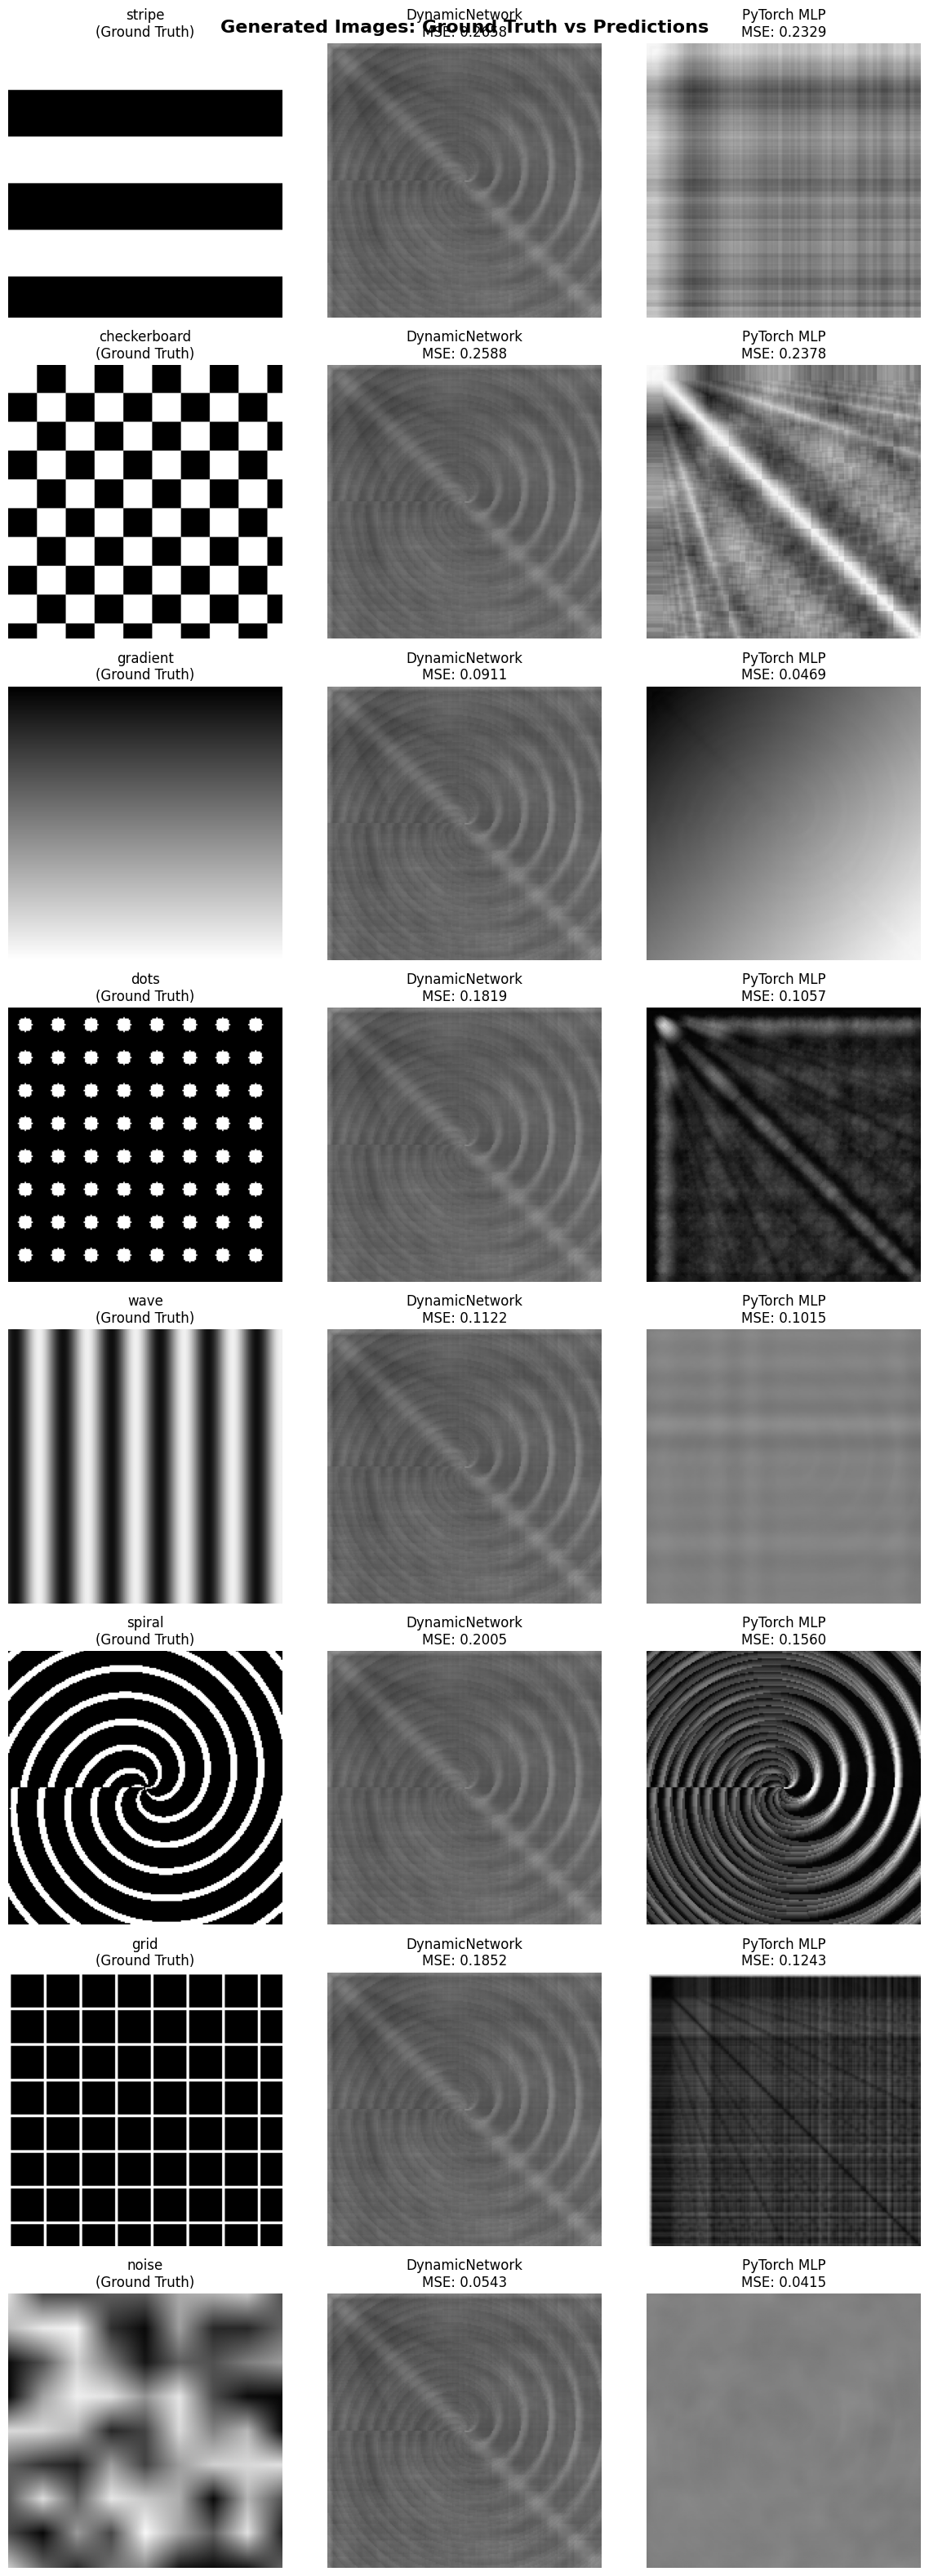

In [25]:
# Visual comparison for each pattern type
fig, axes = plt.subplots(len(PATTERN_TYPES), 3, figsize=(12, 4 * len(PATTERN_TYPES)))

for pattern_idx, pattern_type in enumerate(PATTERN_TYPES):
    # Find a test sample of this pattern type
    sample_idx = np.where(y_test_labels == pattern_idx)[0][0]
    
    # Ground truth
    gt_image = y_test_images[sample_idx].reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    # DNN prediction
    dnn_image = np.clip(dnn_predictions[sample_idx], 0, 1).reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    # MLP prediction  
    mlp_image = np.clip(mlp_predictions[sample_idx], 0, 1).reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    # Calculate per-pattern MSE
    dnn_pattern_mse = np.mean((dnn_predictions[sample_idx] - y_test_images[sample_idx])**2)
    mlp_pattern_mse = np.mean((mlp_predictions[sample_idx] - y_test_images[sample_idx])**2)
    
    # Plot
    axes[pattern_idx, 0].imshow(gt_image, cmap='gray', vmin=0, vmax=1)
    axes[pattern_idx, 0].set_title(f'{pattern_type}\n(Ground Truth)', fontsize=12)
    axes[pattern_idx, 0].axis('off')
    
    axes[pattern_idx, 1].imshow(dnn_image, cmap='gray', vmin=0, vmax=1)
    axes[pattern_idx, 1].set_title(f'DynamicNetwork\nMSE: {dnn_pattern_mse:.4f}', fontsize=12)
    axes[pattern_idx, 1].axis('off')
    
    axes[pattern_idx, 2].imshow(mlp_image, cmap='gray', vmin=0, vmax=1)
    axes[pattern_idx, 2].set_title(f'PyTorch MLP\nMSE: {mlp_pattern_mse:.4f}', fontsize=12)
    axes[pattern_idx, 2].axis('off')

plt.suptitle('Generated Images: Ground Truth vs Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Per-Pattern MSE Analysis

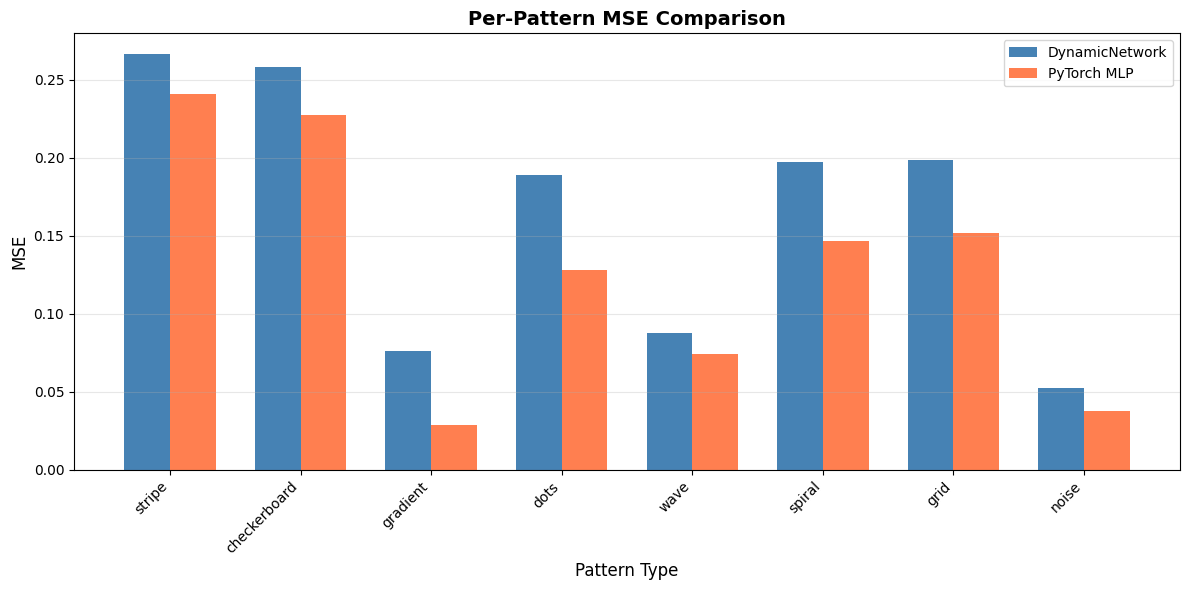


Per-Pattern MSE:
Pattern          DynamicNetwork     PyTorch MLP          Winner
------------------------------------------------------------
stripe                 0.266556        0.240775             MLP
checkerboard           0.258450        0.227756             MLP
gradient               0.076234        0.028582             MLP
dots                   0.189119        0.128450             MLP
wave                   0.087910        0.074309             MLP
spiral                 0.197578        0.146431             MLP
grid                   0.198382        0.151721             MLP
noise                  0.052485        0.037772             MLP


In [26]:
# Per-pattern MSE analysis
pattern_mse_dnn = {}
pattern_mse_mlp = {}

for pattern_idx, pattern_type in enumerate(PATTERN_TYPES):
    mask = y_test_labels == pattern_idx
    
    dnn_pattern_preds = dnn_predictions[mask]
    mlp_pattern_preds = mlp_predictions[mask]
    gt_pattern = y_test_images[mask]
    
    pattern_mse_dnn[pattern_type] = np.mean((dnn_pattern_preds - gt_pattern)**2)
    pattern_mse_mlp[pattern_type] = np.mean((mlp_pattern_preds - gt_pattern)**2)

# Plot per-pattern MSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(PATTERN_TYPES))
width = 0.35

bars1 = ax.bar(x - width/2, list(pattern_mse_dnn.values()), width, 
               label='DynamicNetwork', color='steelblue')
bars2 = ax.bar(x + width/2, list(pattern_mse_mlp.values()), width,
               label='PyTorch MLP', color='coral')

ax.set_xlabel('Pattern Type', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Per-Pattern MSE Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(PATTERN_TYPES, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print table
print("\nPer-Pattern MSE:")
print(f"{'Pattern':<15} {'DynamicNetwork':>15} {'PyTorch MLP':>15} {'Winner':>15}")
print("-" * 60)
for pattern in PATTERN_TYPES:
    winner = "DNN" if pattern_mse_dnn[pattern] < pattern_mse_mlp[pattern] else "MLP"
    print(f"{pattern:<15} {pattern_mse_dnn[pattern]:>15.6f} {pattern_mse_mlp[pattern]:>15.6f} {winner:>15}")

---
## 8. Summary and Conclusions

In [27]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"\nTask: Text-to-Image Pattern Generation")
print(f"  Input: Single word ({len(PATTERN_TYPES)} patterns)")
print(f"  Output: {IMAGE_SIZE}x{IMAGE_SIZE} grayscale image ({OUTPUT_SIZE:,} pixels)")

print(f"\nDynamicNetwork:")
print(f"  MSE: {dnn_mse:.6f}")
print(f"  Training Time: {dnn_time:.2f}s")
print(f"  Parameters: {dnn_params:,}")
print(f"  Layers: {health.current_layers}")
print(f"  Architecture: Adaptive")

print(f"\nPyTorch MLP:")
print(f"  MSE: {mlp_mse:.6f}")
print(f"  Training Time: {mlp_time:.2f}s")
print(f"  Parameters: {mlp_params:,}")
print(f"  Layers: 4 (fixed)")
print(f"  Architecture: 8 -> 64 -> 128 -> 256 -> {OUTPUT_SIZE:,}")

print("\nKey Observations:")
if dnn_mse < mlp_mse:
    print("  1. DynamicNetwork achieves LOWER MSE (better reconstruction)")
else:
    print("  1. PyTorch MLP achieves LOWER MSE (better reconstruction)")
    
if dnn_params < mlp_params:
    param_ratio = mlp_params / dnn_params
    print(f"  2. DynamicNetwork uses {param_ratio:.1f}x FEWER parameters")
else:
    param_ratio = dnn_params / mlp_params
    print(f"  2. PyTorch MLP uses {param_ratio:.1f}x FEWER parameters")

if dnn_time < mlp_time:
    print("  3. DynamicNetwork trains FASTER")
else:
    print("  3. PyTorch MLP trains FASTER")

print("\n" + "=" * 70)

SUMMARY

Task: Text-to-Image Pattern Generation
  Input: Single word (8 patterns)
  Output: 200x200 grayscale image (40,000 pixels)

DynamicNetwork:
  MSE: 0.165839
  Training Time: 206.03s
  Parameters: 681,232
  Layers: 6
  Architecture: Adaptive

PyTorch MLP:
  MSE: 0.129475
  Training Time: 21.32s
  Parameters: 10,322,816
  Layers: 4 (fixed)
  Architecture: 8 -> 64 -> 128 -> 256 -> 40,000

Key Observations:
  1. PyTorch MLP achieves LOWER MSE (better reconstruction)
  2. DynamicNetwork uses 15.2x FEWER parameters
  3. PyTorch MLP trains FASTER



## 9. Save Models

In [28]:
# Save models
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save DynamicNetwork
dnn.save(models_dir, 'text_to_image_dnn')
print(f"DynamicNetwork saved to {models_dir}/text_to_image_dnn.json")

# Save PyTorch model
torch.save(mlp.state_dict(), os.path.join(models_dir, 'text_to_image_mlp.pth'))
print(f"PyTorch MLP saved to {models_dir}/text_to_image_mlp.pth")

# Save encoder
encoder.save(os.path.join(models_dir, 'word_encoder.json'))
print(f"Word encoder saved to {models_dir}/word_encoder.json")

print("\nAll models saved successfully!")

DynamicNetwork saved to ../models/text_to_image_dnn.json
PyTorch MLP saved to ../models/text_to_image_mlp.pth
Word encoder saved to ../models/word_encoder.json

All models saved successfully!
